### Exploratory Data Analysis (EDA)

#### Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading the Dataset

In [2]:
# Updated column names matching the 2025 survey schema
selected_columns = [
    'ResponseId',
    'MainBranch',
    'Employment',
    'RemoteWork',
    'EdLevel',
    'YearsCode',          
    'DevType',
    'Country',
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'ConvertedCompYearly'   
]
print("Loading Dataset...")
df = pd.read_csv("results.csv", usecols=selected_columns) # Selecting only the necessary columns to reduce memory usage
print("Dataset Loaded Successfully with shape:", df.shape)

Loading Dataset...
Dataset Loaded Successfully with shape: (49191, 12)


#### Inspecting the Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ResponseId              49191 non-null  int64  
 1   MainBranch              49191 non-null  str    
 2   EdLevel                 48149 non-null  str    
 3   Employment              48339 non-null  str    
 4   YearsCode               43042 non-null  float64
 5   DevType                 43680 non-null  str    
 6   RemoteWork              33780 non-null  str    
 7   Country                 35437 non-null  str    
 8   LanguageHaveWorkedWith  31671 non-null  str    
 9   DatabaseHaveWorkedWith  25550 non-null  str    
 10  PlatformHaveWorkedWith  24258 non-null  str    
 11  ConvertedCompYearly     23947 non-null  float64
dtypes: float64(2), int64(1), str(9)
memory usage: 4.5 MB


In [4]:
df.head()

,ResponseId,MainBranch,EdLevel,Employment,YearsCode,DevType,RemoteWork,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,ConvertedCompYearly
0,1,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,14.0,"Developer, mobile",Remote,Ukraine,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,61256.0
1,2,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,10.0,"Developer, back-end","Hybrid (some in-person, leans heavy to flexibi...",Netherlands,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,104413.0
2,3,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",12.0,"Developer, front-end",NaN,Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,53061.0
3,4,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,5.0,"Developer, back-end",Remote,Ukraine,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,36197.0
4,5,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",22.0,Engineering manager,NaN,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,60000.0


In [5]:
print('Missing values per column:')
print(df.isnull().sum())

print("Summary Statistics:")
print(f'Total rows: {len(df)}')
print(f"Missing Salaries {df['ConvertedCompYearly'].isnull().sum()} ({(df['ConvertedCompYearly'].isnull().mean() * 100):.1f}%)")

Missing values per column:
ResponseId                    0
MainBranch                    0
EdLevel                    1042
Employment                  852
YearsCode                  6149
DevType                    5511
RemoteWork                15411
Country                   13754
LanguageHaveWorkedWith    17520
DatabaseHaveWorkedWith    23641
PlatformHaveWorkedWith    24933
ConvertedCompYearly       25244
dtype: int64
Summary Statistics:
Total rows: 49191
Missing Salaries 25244 (51.3%)


#### Data Cleaning

##### Filtering out extreme outliers (Keep realistic annual salaries: $5,000 to $500,000)

In [7]:
#  Drop rows where salary is NaN
df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()

#  Filter out extreme outliers (Keep realistic annual salaries: $5,000 to $500,000)
salary_floor = 5000
salary_ceiling = 500000
# Filter the DataFrame to keep only rows within the specified salary range
df_clean = df_clean[
    (df_clean['ConvertedCompYearly'] >= salary_floor) & 
    (df_clean['ConvertedCompYearly'] <= salary_ceiling)
]

print(f"Rows remaining after salary filtering: {len(df_clean)}")

Rows remaining after salary filtering: 22060


##### Changing the data type of 'YearsCode' column to numeric

In [9]:
# Inspect unique non-numeric strings in YearsCode
print("Raw YearsCode unique values preview:", df_clean['YearsCode'].unique()[:10])

# Replace text strings with numeric representations
df_clean['YearsCode'] = df_clean['YearsCode'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
})

# Convert the column to float
df_clean['YearsCode'] = pd.to_numeric(df_clean['YearsCode'], errors='coerce')

# Drop remaining missing experience values
df_clean = df_clean.dropna(subset=['YearsCode'])

print(f"Final usable dataset size: {len(df_clean)} rows")

Raw YearsCode unique values preview: [14. 10. 12.  5. 22. 20. 13. 30. 15.  9.]
Final usable dataset size: 21987 rows


##### Plotting the distribution of salaries

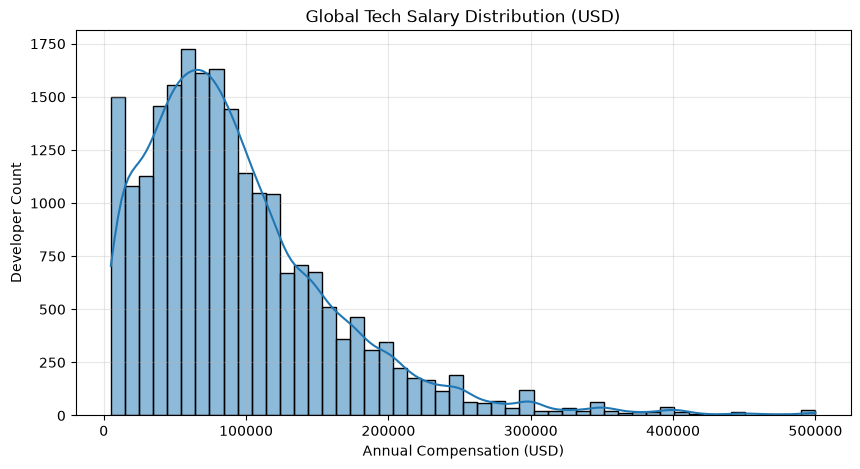

Median Salary: 80640.0
Mean Salary: 95064.96220493928


In [51]:
# Visualizing the salary distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['ConvertedCompYearly'], bins=50, kde=True)
plt.title('Global Tech Salary Distribution (USD)')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Developer Count')
plt.grid(True, alpha=0.3)
plt.savefig('salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Median Salary:", df_clean['ConvertedCompYearly'].median())
print("Mean Salary:", df_clean['ConvertedCompYearly'].mean())


##### Exploding the 'LanguageWorkedWith' column to analyze the popularity of programming languages

In [14]:
# Create a copy with exploded languages
languages_df = df_clean.dropna(subset=['LanguageHaveWorkedWith']).copy()

# Split the string into lists, then explode into individual rows
languages_df['Language'] = languages_df['LanguageHaveWorkedWith'].str.split(';')
languages_exploded = languages_df.explode('Language')

# Strip any residual whitespace
languages_exploded['Language'] = languages_exploded['Language'].str.strip()

print(f"Total individual language entries parsed: {len(languages_exploded)}")

Total individual language entries parsed: 124541


##### Calculating the average salary for each programming language

In [23]:
# Calculate median salary and respondent count per language
lang_stats = languages_exploded.groupby('Language').agg(
    MedianSalary=('ConvertedCompYearly', 'median'),
    Count=('ConvertedCompYearly', 'count')
).reset_index()

# Filter for top languages with at least 500 respondents, sorted by salary
min_respondents = 500
top_languages = lang_stats[lang_stats['Count'] >= min_respondents].sort_values(
    by='MedianSalary', 
    ascending=False
)

# Display top 15 highest-paying languages
top_languages.head(15)

,Language,MedianSalary,Count
33,Ruby,106310.5,1452
36,Scala,104413.0,536
9,Elixir,101437.0,560
28,Perl,100000.0,749
37,Swift,94659.0,1103
15,Go,92812.0,3527
16,Groovy,92812.0,1089
2,Bash/Shell (all shells),87011.0,10473
34,Rust,87011.0,2899
20,Kotlin,83531.0,2236


##### Visualizing the average salary for each programming language using a bar chart

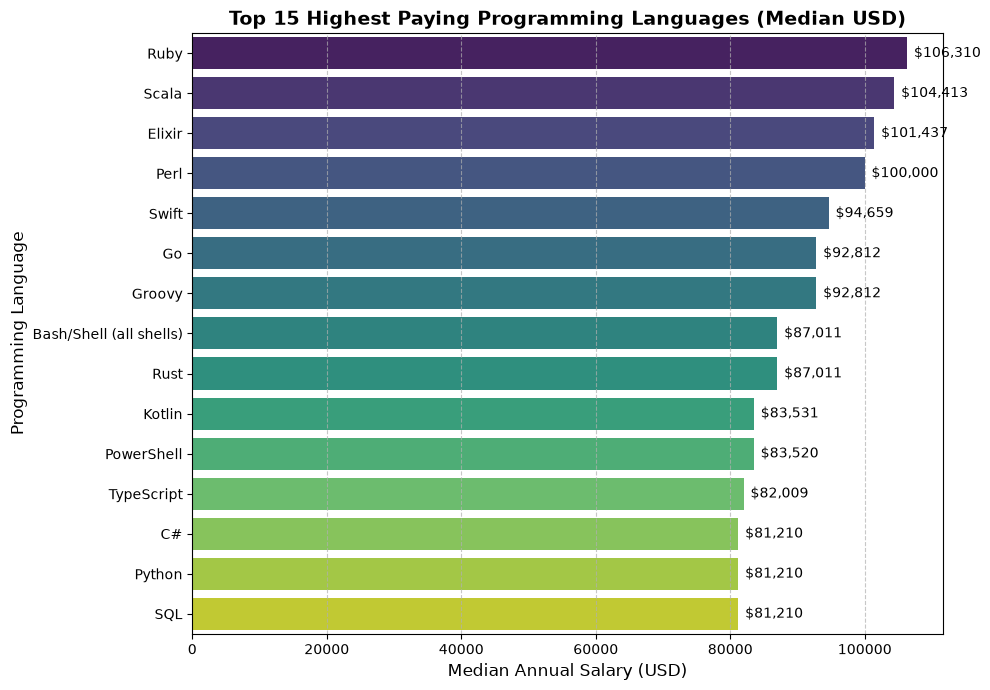

In [50]:
# Visualizing the top 15 highest-paying programming languages
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_languages.head(15),
    x='MedianSalary',
    y='Language',
    hue='Language',
    palette='viridis',
    legend=False
)

plt.title('Top 15 Highest Paying Programming Languages (Median USD)', fontsize=14, fontweight='bold')
plt.xlabel('Median Annual Salary (USD)', fontsize=12)
plt.ylabel('Programming Language', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add salary data labels to each bar
for index, value in enumerate(top_languages.head(15)['MedianSalary']):
    plt.text(value + 1000, index, f"${int(value):,}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_languages_salary.png', dpi=300, bbox_inches='tight')
plt.show()


##### Inspection whether remote workers versus on site workers have different salary distributions

In [ ]:
# 1. Inspect unique remote work categories
print("Remote Work categories:", df_clean['RemoteWork'].unique())

# 2. Group by RemoteWork and calculate median salary + respondent count
remote_stats = df_clean.groupby('RemoteWork').agg(MedianSalary=('ConvertedCompYearly', 'median'),MeanSalary=('ConvertedCompYearly', 'mean'),Count=('ConvertedCompYearly', 'count')
).reset_index().sort_values(by='MedianSalary', ascending=False)

print("\n--- Remote Work Compensation Breakdown ---")
print(remote_stats)

Remote Work categories: <StringArray>
[                                                                      'Remote',
                          'Hybrid (some in-person, leans heavy to flexibility)',
                                                                            nan,
                               'Hybrid (some remote, leans heavy to in-person)',
 'Your choice (very flexible, you can come in when you want or just as needed)',
                                                                    'In-person']
Length: 6, dtype: str

--- Remote Work Compensation Breakdown ---
                                          RemoteWork  MedianSalary  \
3                                             Remote       94552.0   
0  Hybrid (some in-person, leans heavy to flexibi...       81509.0   
4  Your choice (very flexible, you can come in wh...       79223.0   
1     Hybrid (some remote, leans heavy to in-person)       75410.0   
2                                          In-person       5

##### Visualization (Remote vs On-site Salary Distribution)

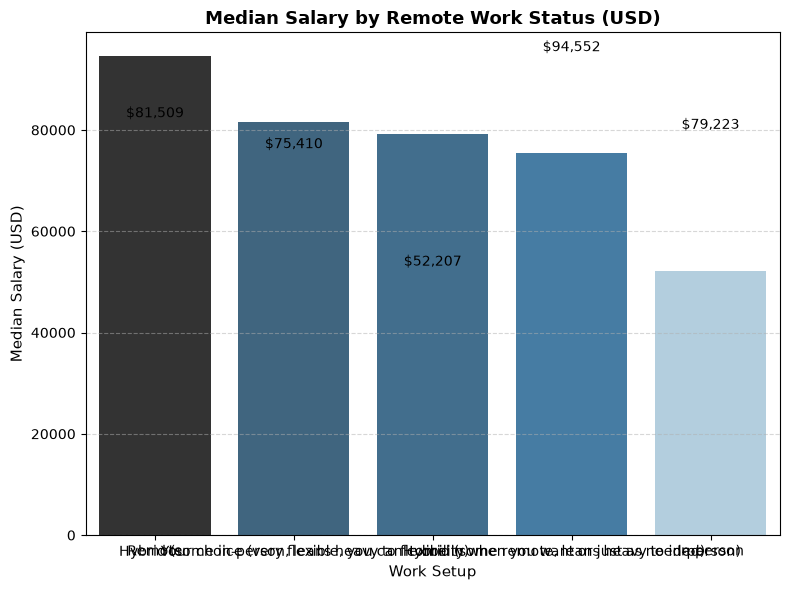

In [52]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=remote_stats,
    x='RemoteWork',
    y='MedianSalary',
    hue = 'MedianSalary',
    legend=False,
    palette='Blues_d'
)

plt.title('Median Salary by Remote Work Status (USD)', fontsize=13, fontweight='bold')
plt.xlabel('Work Setup', fontsize=11)
plt.ylabel('Median Salary (USD)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for index, row in remote_stats.iterrows():
    plt.text(index, row['MedianSalary'] + 1000, f"${int(row['MedianSalary']):,}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('remote_work_salary.png', dpi=300, bbox_inches='tight')
plt.show()


##### Geograhic Disparity in Salary Distribution

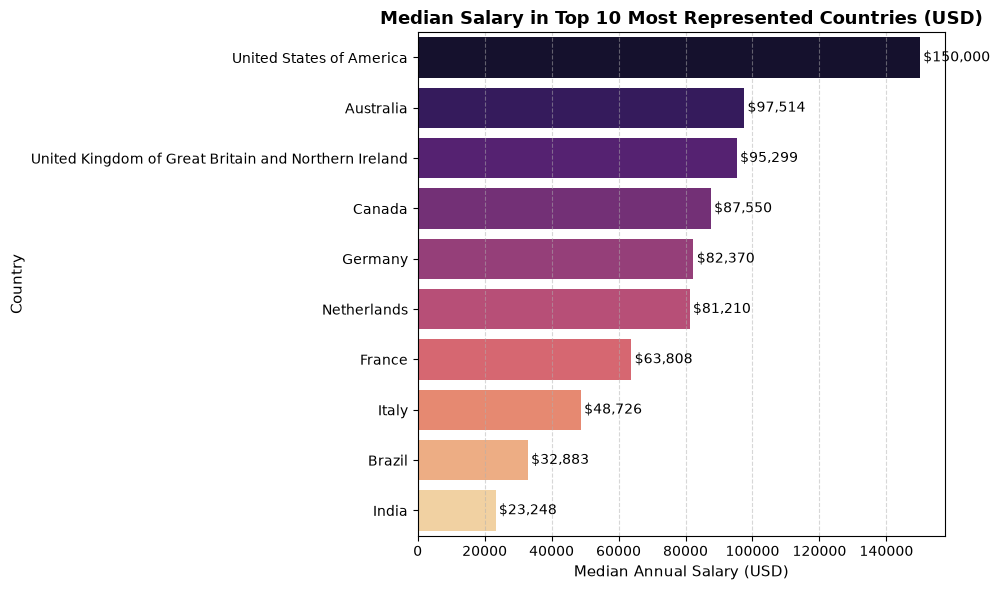

In [53]:
# Group by country and calculate stats
country_stats = df_clean.groupby('Country').agg(
    MedianSalary=('ConvertedCompYearly', 'median'),
    Count=('ConvertedCompYearly', 'count')
).reset_index()

# Filter for Top 10 countries by respondent count
top_countries = country_stats.sort_values(by='Count', ascending=False).head(10)
top_countries = top_countries.sort_values(by='MedianSalary', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_countries,
    x='MedianSalary',
    y='Country',
    hue= 'Country',
    legend=False,
    palette='magma'
)

plt.title('Median Salary in Top 10 Most Represented Countries (USD)', fontsize=13, fontweight='bold')
plt.xlabel('Median Annual Salary (USD)', fontsize=11)
plt.ylabel('Country', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for index, value in enumerate(top_countries['MedianSalary']):
    plt.text(value + 1000, index, f"${int(value):,}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig("top_countries_salary.png", dpi=300, bbox_inches='tight')
plt.show()


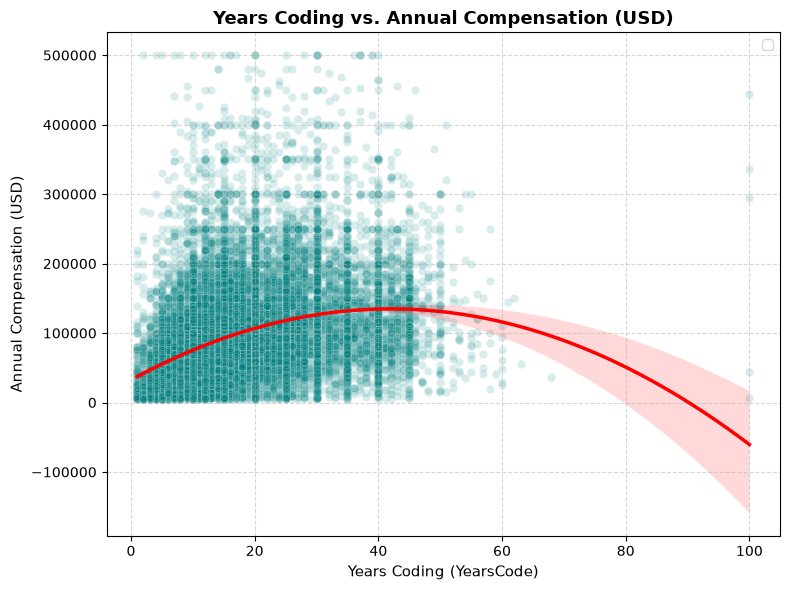

Pearson Correlation between Experience and Salary: 0.34


In [54]:
plt.figure(figsize=(8, 6))

# 1. Scatter plot with transparency to reduce overplotting
sns.scatterplot(
    data=df_clean,
    x='YearsCode',
    y='ConvertedCompYearly',
    legend=False,
    alpha=0.15,
    color='teal'
)

# 2. Add a trendline using lowess or a polynomial regression line
sns.regplot(
    data=df_clean,
    x='YearsCode',
    y='ConvertedCompYearly',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2.5},
    order=2,
    label='Polynomial Trendline'
)

plt.title('Years Coding vs. Annual Compensation (USD)', fontsize=13, fontweight='bold')
plt.xlabel('Years Coding (YearsCode)', fontsize=11)
plt.ylabel('Annual Compensation (USD)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Quantify correlation
correlation = df_clean['YearsCode'].corr(df_clean['ConvertedCompYearly'])
print(f"Pearson Correlation between Experience and Salary: {correlation:.2f}")